In [1]:
# investigate circuit of the form
# ZZ(theta1).SWAP(theta2)
from qiskit.circuit.library import RZZGate, SwapGate
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from gulps.core.invariants import GateInvariants
import numpy as np

In [2]:
def ansatz(theta1, theta2):
    qc = QuantumCircuit(2)
    qc.append(RZZGate(np.pi / 2).power(theta1), [0, 1])
    qc.append(SwapGate().power(theta2), [0, 1])
    return Operator(qc)

In [3]:
N = 10_000
invariant_list = []

for _ in range(N):
    r1, r2 = np.random.rand(2)
    U = ansatz(r1, r2)
    invariant_list.append(GateInvariants.from_unitary(U))

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

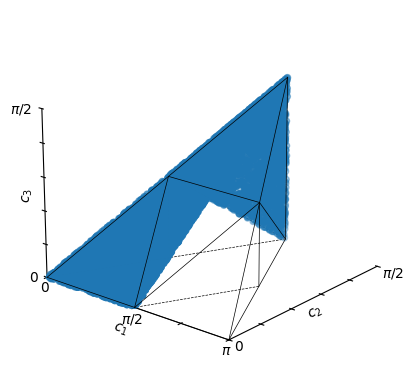

In [4]:
from gulps.viz.invariant_viz import scatter_plot
from matplotlib import pyplot as plt

%matplotlib inline
scatter_plot(invariant_list)